# ðŸ“– Tutorial: Training a Disordered FNQS with NetKet Pro

Ce notebook explique comment dÃ©finir, optimiser et Ã©valuer un Ã©tat quantique neuronal fondationnel (FNQS) soumis Ã  un dÃ©sordre structurel (ici un champ magnÃ©tique alÃ©atoire) Ã  l'aide de `netket_foundational` (nkf).

## 1. Theoretical Background

Nous Ã©tudions le modÃ¨le d'Ising 1D en champ transverse avec dÃ©sordre. L'Hamiltonien paramÃ©trÃ© pour une taille de systÃ¨me $L$ est dÃ©fini par :

$$\mathcal{H}(\{h_i\}) = - \sum_{i=1}^{L} h_i \sigma_i^x - J \sum_{i=1}^{L} \sigma_i^z \sigma_{i+1}^z$$

oÃ¹ $J$ est l'interaction d'Ã©change et $h_i$ reprÃ©sente le champ magnÃ©tique local. Le dÃ©sordre est introduit en tirant les $h_i$ d'une distribution statistique (par exemple gaussienne autour d'une moyenne $h_0$).

Pour Ã©valuer la prÃ©cision de l'Ansatz (ViTFNQS), nous utilisons deux mÃ©triques :
* **V-score** : Quantifie la prÃ©cision de l'Ã©nergie variationnelle. $V = \frac{\text{Var}(\mathcal{H})}{\langle \mathcal{H} \rangle^2}$. Une valeur tendant vers 0 indique un Ã©tat propre exact.
* **$\hat{R}$ (R-hat)** : La statistique de Gelman-Rubin. Elle vÃ©rifie la convergence des chaÃ®nes de Markov du sampler de Monte Carlo. Un $\hat{R} \approx 1$ (gÃ©nÃ©ralement $< 1.01$) garantit que l'Ã©chantillonnage est reprÃ©sentatif de la distribution de probabilitÃ© $|\psi(x)|^2$.

## 2. Configuration & Imports

In [8]:
exposer la théorie
faire le calcul exact pour les petites tailles 
début : juste train + plot énergie, Vscore, MZ**2
ensuite:
    bloc de tests
    Rhat : montre la qualité de convergence des MCMC
    problème en h0=0
    termaliser les chaînes 
    dérivée de MZ (à voir)
    entrainement par epoch (plutôt non)
    comment enregistrer les données des trains et les récupérer les plots 
    adaptation en 2D
    global flip
    paralel tempering 

SyntaxError: invalid decimal literal (907950740.py, line 12)

In [ ]:
import os
os.environ["NETKET_EXPERIMENTAL_SHARDING"] = "1"
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import netket as nk
import netket_foundational as nkf
import jax
import jax.numpy as jnp
import numpy as np
from tqdm import tqdm
import optax
import matplotlib.pyplot as plt
from netket_foundational._src.model.vit import ViTFNQS

## 3. System Definition and Disorder Realizations

Nous dÃ©finissons l'espace de Hilbert et gÃ©nÃ©rons un batch de champs magnÃ©tiques dÃ©sordonnÃ©s. L'approche FNQS permet d'optimiser en parallÃ¨le toutes ces rÃ©alisations (rÃ©plicas).

In [ ]:
L = 25
J_val = 1.0
h0_list = [0.5, 1.0, 1.5]
sigma = 0.1
n_replicas = 10

hi = nk.hilbert.Spin(0.5, L)
ps = nkf.ParameterSpace(N=hi.size, min=0, max=10*max(h0_list))

def generate_multi_h0_disorder(h0_list, n_reps, system_size, sigma, rng=np.random.default_rng(1)):
    all_configs = []
    for h_m in h0_list:
        raw_configs = rng.normal(loc=h_m, scale=sigma, size=(n_reps, system_size))
        random_configs = np.abs(raw_configs)
        all_configs.append(random_configs)
    return np.vstack(all_configs)

params_list = generate_multi_h0_disorder(h0_list, n_replicas, hi.size, sigma)
total_configs = params_list.shape[0]

## 4. The ViTFNQS Ansatz

Nous utilisons un Vision Transformer adaptÃ© aux Ã©tats quantiques.
Puisque le modÃ¨le n'est pas invariant par translation (Ã  cause du dÃ©sordre local $h_i$), nous configurons l'Ansatz avec `disorder=True` et `transl_invariant=False`.

In [ ]:
ma = ViTFNQS(
    num_layers=2,
    d_model=16,
    heads=4,
    b=1,
    L_eff=L, 
    n_coups=ps.size, 
    complex=True, 
    disorder=True, 
    transl_invariant=False, 
    two_dimensional=False, 
)

## 5. Variational Monte Carlo Setup

La parallÃ©lisation sur plusieurs configurations matÃ©rielles est gÃ©rÃ©e par `n_replicas` au sein du `FoundationalQuantumState`.

In [ ]:
sa = nk.sampler.MetropolisLocal(hi, n_chains=total_configs * 4)

vs = nkf.FoundationalQuantumState(
    sa, ma, ps, 
    n_replicas=total_configs, 
    n_samples=total_configs * 4 * 16, 
    seed=1
)
vs.parameter_array = params_list

def create_operator(params):
    ha_X = sum(params[i] * nkf.operator.sigmax(hi, i) for i in range(hi.size))
    ha_ZZ = sum(nkf.operator.sigmaz(hi, i) @ nkf.operator.sigmaz(hi, (i + 1) % hi.size) for i in range(hi.size))
    return -ha_X - J_val * ha_ZZ

ha_p = nkf.operator.ParametrizedOperator(hi, ps, create_operator)

/users/eleves-a/2024/nikola.audit/NeuralNetworkQuantumStates/netket_pro/experiments/netket_foundational/_src/vqs/state.py:335: FutureWarning: Call to deprecated function 'check_chunk_size' (This function has been removed. People should be free to use the chunk size they prefer.)
  check_chunk_size(n_samples, self.chunk_size)


## 6. Optimization

EntraÃ®nement simultanÃ© de toutes les rÃ©plicas via descente de gradient stochastique (VMC).

In [6]:
lr_schedule = optax.linear_schedule(init_value=0.03, end_value=0.005, transition_steps=300)
optimizer = optax.sgd(lr_schedule)

def cg_solver(A, b):
    return jax.scipy.sparse.linalg.cg(A, b, tol=1e-4)[0]

gs = nkf.VMC_NG(ha_p, optimizer, variational_state=vs, diag_shift=2e-4, linear_solver_fn=cg_solver)

log = nk.logging.JsonLog("logs/disorder_run", save_params=False)

gs.run(n_iter=150, out=log, obs={"ham": ha_p})

100%|██████████| 150/150 [29:40<00:00, 11.87s/it, Energy=-33.4+0.0j ± 1.1 [σ²=3.9e+01]]


(JsonLog('logs/disorder_run', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.7634177207946777
   	Params: 0.0,)

## 7. Diagnostics : V-Score & $\hat{R}$

Nous Ã©valuons la prÃ©cision (V-score) et la qualitÃ© d'Ã©chantillonnage ($\hat{R}$) du modÃ¨le entraÃ®nÃ© pour chaque rÃ©alisation du dÃ©sordre.

<>:33: SyntaxWarning: invalid escape sequence '\h'
<>:34: SyntaxWarning: invalid escape sequence '\h'
<>:33: SyntaxWarning: invalid escape sequence '\h'
<>:34: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1165331/2516809505.py:33: SyntaxWarning: invalid escape sequence '\h'
  plt.title("Distribution de R-hat ($\hat{R}$)")
/tmp/ipykernel_1165331/2516809505.py:34: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel("$\hat{R}$")


Ã‰valuation des mÃ©triques finales...


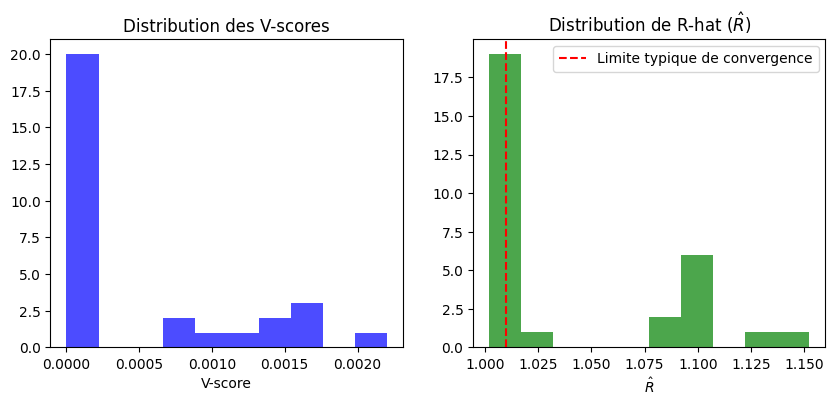

In [7]:
v_scores = []
r_hats = []

print("Ã‰valuation des mÃ©triques finales...")
for r in range(total_configs):
    pars = params_list[r]
    _vs = vs.get_state(pars)
    
    vs_mc = nk.vqs.MCState(
        sampler=nk.sampler.MetropolisLocal(hi, n_chains=16), 
        model=_vs.model, 
        variables=_vs.variables, 
        n_samples=2048
    )
    
    _ha = create_operator(pars)
    stats = vs_mc.expect(_ha)
    
    val = stats.variance / (stats.Mean.real**2 + 1e-12)
    v_scores.append(val)
    
    r_hats.append(stats.R_hat)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(v_scores, bins=10, color='blue', alpha=0.7)
plt.title("Distribution des V-scores")
plt.xlabel("V-score")

plt.subplot(1, 2, 2)
plt.hist(r_hats, bins=10, color='green', alpha=0.7)
plt.axvline(1.01, color='red', linestyle='dashed', label='Limite typique de convergence')
plt.title("Distribution de R-hat ($\hat{R}$)")
plt.xlabel("$\hat{R}$")
plt.legend()
plt.show()